In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
import os

os.getcwd()
os.chdir("CSV-Data")

In [6]:
df = pd.read_csv("rotation_schedule_data_2023-25deid.csv")

# 1. Create a cleaned status column
# Mapping the archived versions to their non-archived counterparts
status_map = {
    'Archived (Completed)': 'Completed',
    'Completed': 'Completed',
    'Archived (Withdrawn)': 'Withdrawn',
    'Withdrawn': 'Withdrawn',
    'Archived (Denied)': 'Denied',
    'Denied': 'Denied'
}

df['Cleaned Status'] = df['Status'].replace(status_map)

In [7]:
# 2. Ensure Start Date is in datetime format to extract time components
df['Start Date'] = pd.to_datetime(df['Start Date'])

# 3. Create the Year column
df['Year'] = df['Start Date'].dt.year

# 4. Create the Cohort column (Spring/Fall logic)
# Spring is typically months 1-6, Fall is 7-12
df['Cohort'] = df['Start Date'].dt.month.apply(lambda x: 'Spring' if x <= 6 else 'Fall') + " " + df['Year'].astype(str)

# View the first few rows to verify the new columns
df[['Rotation ID', 'Start Date', 'Status', 'Cleaned Status', 'Year', 'Cohort']].head()

/var/folders/dp/thm1j60170gcs56x3n66bt3h0000gn/T/ipykernel_46404/2043589718.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Start Date'] = pd.to_datetime(df['Start Date'])


,Rotation ID,Start Date,Status,Cleaned Status,Year,Cohort
0,312937.0,2023-01-09,Archived (Completed),Completed,2023.0,Spring 2023.0
1,312939.0,2023-05-08,Archived (Denied),Denied,2023.0,Spring 2023.0
2,312940.0,2023-05-12,Archived (Denied),Denied,2023.0,Spring 2023.0
3,312944.0,2023-01-09,Archived (Withdrawn),Withdrawn,2023.0,Spring 2023.0
4,312945.0,2023-01-13,Archived (Withdrawn),Withdrawn,2023.0,Spring 2023.0


In [8]:
# 4. Create the Tier Mapping
# Tier 1 keywords (Premier)
tier_1_keywords = [
    'emory', 'ksu', 'mercer', 'gsu', 'georgia state university',
    'middle ga state university', 'middle georgia state', 'central ga tech', 'central georgia tech',
    'chamberlain', 'university north ga', 'university of north georgia',
    'fort valley state university', 'ga college & state university', 'georgia college & state',
    'ga gwinnett college', 'georgia gwinnett'
]

# Tier 2 keywords (Preferred)
tier_2_keywords = [
    'albany state', 'auburn', 'brenau', 'ga southern', 'georgia southern',
    'university of west ga', 'university of west georgia',
    'clemson university', 'augusta university'
]

def assign_tier(school):
    if pd.isna(school):
        return 0

    school_lower = str(school).lower()

    # Check for Tier 1 matches
    if any(keyword in school_lower for keyword in tier_1_keywords):
        return 1

    # Check for Tier 2 matches
    if any(keyword in school_lower for keyword in tier_2_keywords):
        return 2

    # Default if no match
    return 0

# Apply the tier logic
df['tier'] = df['Schools'].apply(assign_tier)

# --- Verification ---
# Display first few rows of the relevant columns
print(df[['Schools', 'tier', 'Cleaned Status', 'Year', 'Cohort']].head())

                                    Schools  tier Cleaned Status    Year  \
0  Chamberlain College of Nursing - Georgia     1      Completed  2023.0   
1  Chamberlain College of Nursing - Georgia     1         Denied  2023.0   
2  Chamberlain College of Nursing - Georgia     1         Denied  2023.0   
3  Chamberlain College of Nursing - Georgia     1      Withdrawn  2023.0   
4  Chamberlain College of Nursing - Georgia     1      Withdrawn  2023.0   

          Cohort  
0  Spring 2023.0  
1  Spring 2023.0  
2  Spring 2023.0  
3  Spring 2023.0  
4  Spring 2023.0  


In [11]:
pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 7.2 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


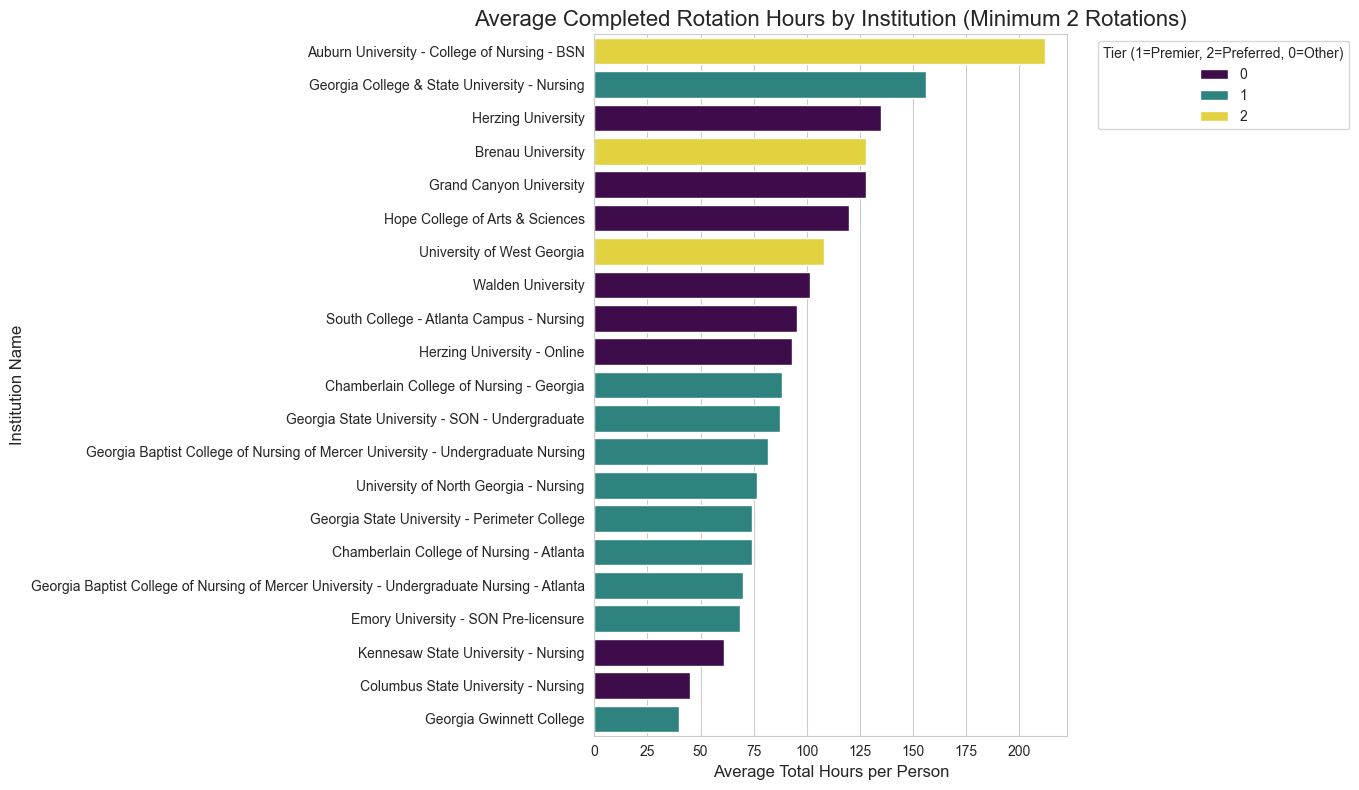

Summary by Tier:
       Avg Hours  Number of Schools
tier                               
0      97.338370                  8
1      81.688816                 10
2     149.333333                  3


In [12]:
# 1. Filter for 'Completed' rotations using our new Cleaned Status column
df_completed = df[df['Cleaned Status'] == 'Completed'].copy()

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter for institutions with at least 2 completed rotations
# This ensures we don't have outliers from schools with only a single entry
school_counts = df_completed['Schools'].value_counts()
schools_to_keep = school_counts[school_counts >= 2].index
df_filtered = df_completed[df_completed['Schools'].isin(schools_to_keep)]

# 2. Group by School and Tier to calculate average hours
avg_hours_per_school = df_filtered.groupby(['Schools', 'tier'])['Total Hours per Person'].mean().reset_index()

# Sort by hours for better visualization
avg_hours_per_school = avg_hours_per_school.sort_values(by='Total Hours per Person', ascending=False)

# 3. Create the Visualization
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Bar plot showing Schools, colored by their Tier
plot = sns.barplot(
    data=avg_hours_per_school,
    x='Total Hours per Person',
    y='Schools',
    hue='tier',
    palette='viridis',
    dodge=False # Keeps bars aligned if multiple tiers share a school name (rare)
)

# Formatting the chart
plt.title('Average Completed Rotation Hours by Institution (Minimum 2 Rotations)', fontsize=16)
plt.xlabel('Average Total Hours per Person', fontsize=12)
plt.ylabel('Institution Name', fontsize=12)
plt.legend(title='Tier (1=Premier, 2=Preferred, 0=Other)', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# 4. --- Summary Statistics by Tier ---
# Calculate the average hours across each tier group
tier_summary = avg_hours_per_school.groupby('tier')['Total Hours per Person'].agg(['mean', 'count']).rename(columns={'mean': 'Avg Hours', 'count': 'Number of Schools'})
print("Summary by Tier:")
print(tier_summary)